<a href="https://colab.research.google.com/github/Nodias/csot-ml-astronomy/blob/main/week1_data_solution_UPDATED.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# CSoT'26 — ML in Astronomy — Week 1 · Part 2: Data Pipeline (Solution)

Reference implementation. **Only open after attempting [`week1_data_starter.ipynb`](week1_data_starter.ipynb).**

Structure mirrors the starter, with code filled in and short commentary on the *why*. Companion reading: [`08-data-pipelines.md`](../08-data-pipelines.md).

## Step 0 — Imports

In [1]:
import os
import random
from pathlib import Path

import pandas as pd
import torch
from torch.utils.data import DataLoader, random_split
from torchvision import transforms
from torchvision.datasets import ImageFolder
import torchvision
import matplotlib.pyplot as plt

device = torch.accelerator.current_accelerator().type if torch.accelerator.is_available() else "cpu"
print(f"Using {device} device")

Using cuda device


## Step 1 — Get the dataset into Colab

Using the Kaggle API. You need a free Kaggle account and an API token (`kaggle.json` from Account → Create New API Token).

The download gives a **flat** image archive plus a filename mapping CSV — not class subfolders. We fetch morphology labels separately from the official GZ2 catalogue ([Hart et al. 2016](https://data.galaxyzoo.org/)).

If you've already downloaded/unzipped in a previous session (e.g. to Drive), set the paths below and skip the shell commands.

In [12]:
RAW_ROOT = Path("galaxy_raw")
IMAGES_DIR = RAW_ROOT / "images_gz2" / "images"
DATA_ROOT = Path("galaxy_data")
LABELS_URL = "https://gz2hart.s3.amazonaws.com/gz2_hart16.csv.gz"

# --- Download via Kaggle API (run once) ---
# from google.colab import files
# files.upload()  # select kaggle.json
# !mkdir -p ~/.kaggle && cp kaggle.json ~/.kaggle/kaggle.json
# !pip -q install kaggle pandas
# !kaggle datasets download -d jaimetrickz/galaxy-zoo-2-images
# !unzip -q -o galaxy-zoo-2-images.zip -d {RAW_ROOT}
# !wget -q -O {RAW_ROOT}/gz2_hart16.csv.gz {LABELS_URL}
# !gunzip -f {RAW_ROOT}/gz2_hart16.csv.gz

print("RAW_ROOT   =", RAW_ROOT)
print("IMAGES_DIR =", IMAGES_DIR)
print("DATA_ROOT  =", DATA_ROOT)

RAW_ROOT   = galaxy_raw
IMAGES_DIR = galaxy_raw/images_gz2/images
DATA_ROOT  = galaxy_data


In [ ]:
get_ipython().run_cell_id("0e2ab1e8")

In [ ]:
get_ipython().run_cell_id("d2d9883a")

In [ ]:
get_ipython().run_cell_id("66228c01")

## Step 2 — Inspect the raw layout

Always look at the raw files before trusting `ImageFolder`. The Kaggle bundle stores `{asset_id}.jpg` in one folder and keeps labels in CSV catalogues — not in directory names.

In [14]:
print("RAW_ROOT contents:", sorted(p.name for p in RAW_ROOT.iterdir()))
jpg_count = sum(1 for _ in IMAGES_DIR.glob("*.jpg"))
print(f"Flat JPG count in {IMAGES_DIR}: {jpg_count:,}")

# List 30 images to verify
print(f"Listing 30 images from {IMAGES_DIR}:")
for i, img_path in enumerate(IMAGES_DIR.glob("*.jpg")):
    if i >= 30:
        break
    print(img_path.name)

mapping_head = pd.read_csv(RAW_ROOT / "gz2_filename_mapping.csv", nrows=3)
print(mapping_head)

mapping_head2 = pd.read_csv(RAW_ROOT / "gz2_hart16.csv", nrows=3) #gz2 class at index 7
print(mapping_head2)

RAW_ROOT contents: ['gz2_filename_mapping.csv', 'gz2_hart16.csv', 'images_gz2']
Flat JPG count in galaxy_raw/images_gz2/images: 243,434
Listing 30 images from galaxy_raw/images_gz2/images:
129893.jpg
269557.jpg
223555.jpg
92378.jpg
90024.jpg
22112.jpg
155435.jpg
131741.jpg
66448.jpg
156580.jpg
24247.jpg
1384.jpg
201901.jpg
76833.jpg
45147.jpg
245353.jpg
105854.jpg
189028.jpg
58252.jpg
176433.jpg
246026.jpg
84356.jpg
13228.jpg
86588.jpg
251241.jpg
218273.jpg
73875.jpg
55491.jpg
216359.jpg
167680.jpg
                objid    sample  asset_id
0  587722981736120347  original         1
1  587722981736579107  original         2
2  587722981741363294  original         3
             dr7objid          ra        dec     rastring    decstring  \
0  587732591714893851  179.042984  60.522518  11:56:10.32  +60:31:21.1   
1  588009368545984617  135.084396  52.494240  09:00:20.26  +52:29:39.3   
2  587732484359913515  183.371979  50.741508  12:13:29.27  +50:44:29.4   

     sample gz2_class  total_cl

## Step 3 — Join labels and build an ImageFolder layout

We merge the mapping CSV with Hart et al. (2016) Table 1, collapse `gz2_class` to a few high-level buckets, then symlink a balanced subset into `DATA_ROOT/<class>/`.

This keeps the Week 1 focus on `ImageFolder` while respecting how the real dataset is actually packaged.

In [15]:
def high_level_label(gz2_class: str):
    """Collapse detailed GZ2 morphology codes to a few training buckets."""
    if not gz2_class or gz2_class == "A":
        return None  # artifact / ambiguous — skip
    if gz2_class.startswith("E"):
        return "elliptical"
    if gz2_class.startswith("SB"):
        return "spiral_barred"
    if gz2_class.startswith("S"):
        return "spiral"
    return None


def build_imagefolder_layout(
    images_dir,
    mapping_csv,
    labels_csv,
    out_root,
    per_class=200,
    seed=42,
):
    """Symlink a balanced subset into out_root/<class>/ for ImageFolder."""
    mapping = pd.read_csv(mapping_csv)
    labels = pd.read_csv(labels_csv).rename(columns={"dr7objid": "objid"})
    df = mapping.merge(labels[["objid", "gz2_class"]], on="objid", how="inner")
    df["label"] = df["gz2_class"].map(high_level_label)
    df = df.dropna(subset=["label"])

    images_dir = Path(images_dir)
    out_root = Path(out_root)
    out_root.mkdir(parents=True, exist_ok=True)

    counts = {}
    for label in sorted(df["label"].unique()):
        class_dir = out_root / label
        class_dir.mkdir(exist_ok=True)
        rows = df[df["label"] == label]
        if len(rows) > per_class:
            rows = rows.sample(n=per_class, random_state=seed)
        linked = 0
        for _, row in rows.iterrows():
            src = images_dir / f"{int(row.asset_id)}.jpg"
            dst = class_dir / f"{int(row.asset_id)}.jpg"
            if src.exists() and not dst.exists():
                os.symlink(src.resolve(), dst)
                linked += 1
        counts[label] = linked
    return counts

PER_CLASS = 500  # balanced subset — fast on Colab; increase once the pipeline works
counts = build_imagefolder_layout(
    IMAGES_DIR,
    RAW_ROOT / "gz2_filename_mapping.csv",
    RAW_ROOT / "gz2_hart16.csv",
    DATA_ROOT,
    per_class=PER_CLASS,
)
print("Symlinked per class:", counts)
print("DATA_ROOT classes:", sorted(p.name for p in DATA_ROOT.iterdir() if p.is_dir()))

Symlinked per class: {'elliptical': 500, 'spiral': 500, 'spiral_barred': 500}
DATA_ROOT classes: ['elliptical', 'spiral', 'spiral_barred']


## Step 4 — Transforms pipeline

Order matters: `Resize` (known size) → `ToTensor` (PIL→tensor, 0-255→0-1) → `Normalize` (per-channel standardisation). With mean=std=0.5 the 0–1 range maps to roughly [-1, 1].

In [16]:
transform = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5]),
])

## Step 5 — ImageFolder

`ImageFolder` reads labels from the folder names we created in Step 3 and assigns indices alphabetically. Always inspect `class_to_idx` so you can map predictions back to names later.

In [17]:
dataset = ImageFolder(root=DATA_ROOT, transform=transform)
print("num images   :", len(dataset))
print("classes      :", dataset.classes)
print("class_to_idx :", dataset.class_to_idx)

num images   : 1500
classes      : ['elliptical', 'spiral', 'spiral_barred']
class_to_idx : {'elliptical': 0, 'spiral': 1, 'spiral_barred': 2}


## Step 6 — A single sample

In [18]:
image, label = dataset[0]
print("shape :", image.shape)   # torch.Size([3, 64, 64])
print("dtype :", image.dtype)   # torch.float32
print("label :", label, "->", dataset.classes[label])

shape : torch.Size([3, 64, 64])
dtype : torch.float32
label : 0 -> elliptical


## Step 7 — DataLoader and one batch

In [19]:
loader = DataLoader(dataset, batch_size=32, shuffle=True, num_workers=2, pin_memory=True)

images, labels = next(iter(loader))
print("images:", images.shape)   # (32, 3, 64, 64) = (B, C, H, W)
print("labels:", labels.shape)   # (32,)

images: torch.Size([32, 3, 64, 64])
labels: torch.Size([32])


## Step 8 — Plot a batch

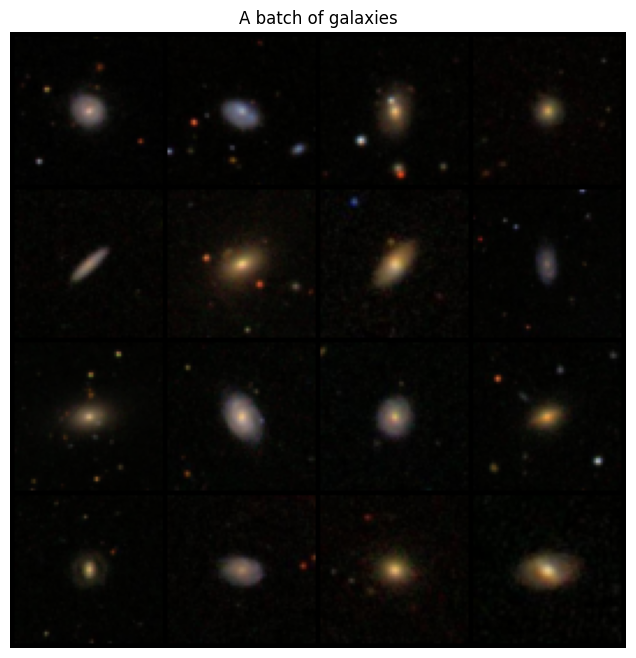

Labels: ['spiral', 'elliptical', 'elliptical', 'spiral', 'spiral', 'elliptical', 'elliptical', 'spiral_barred', 'elliptical', 'spiral', 'spiral', 'spiral_barred', 'spiral_barred', 'spiral', 'elliptical', 'spiral_barred']


In [20]:
images_show = images * 0.5 + 0.5
grid = torchvision.utils.make_grid(images_show[:16], nrow=4)

plt.figure(figsize=(8, 8))
plt.imshow(grid.permute(1, 2, 0).cpu().numpy())
plt.axis("off")
plt.title("A batch of galaxies")
plt.show()

print("Labels:", [dataset.classes[i] for i in labels[:16].tolist()])

## Stretch Goal 1 — Reproducible train/val split

In [21]:
n_val = int(0.15 * len(dataset))
n_train = len(dataset) - n_val
train_subset, val_subset = random_split(
    dataset, [n_train, n_val],
    generator=torch.Generator().manual_seed(42),
)
print(f"train: {len(train_subset)}  val: {len(val_subset)}")

train: 1275  val: 225


## Stretch Goal 2 — Real per-channel mean/std

In [22]:
stat_ds = ImageFolder(
    root=DATA_ROOT,
    transform=transforms.Compose([transforms.Resize((64, 64)), transforms.ToTensor()]),
)
stat_loader = DataLoader(stat_ds, batch_size=64, shuffle=False, num_workers=2)

n_pixels = 0
channel_sum = torch.zeros(3)
channel_sq_sum = torch.zeros(3)
for imgs, _ in stat_loader:
    channel_sum += imgs.sum(dim=[0, 2, 3])
    channel_sq_sum += (imgs ** 2).sum(dim=[0, 2, 3])
    n_pixels += imgs.shape[0] * imgs.shape[2] * imgs.shape[3]

mean = channel_sum / n_pixels
std = (channel_sq_sum / n_pixels - mean ** 2).sqrt()
print("per-channel mean:", mean.tolist())
print("per-channel std :", std.tolist())

per-channel mean: [0.044066671282052994, 0.039014797657728195, 0.028847916051745415]
per-channel std : [0.0846443846821785, 0.06998547166585922, 0.06161487102508545]


## Stretch Goal 4 — Augmentation preview

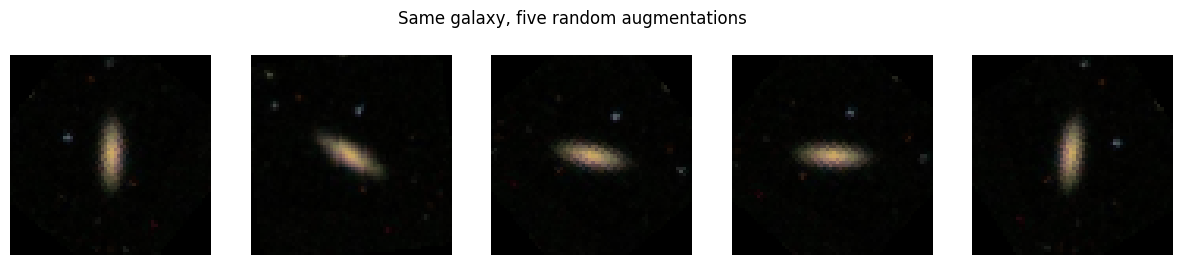

In [23]:
aug = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(180),
    transforms.ToTensor(),
])

img_path, _ = dataset.samples[0]
from PIL import Image
pil_img = Image.open(img_path).convert("RGB")

fig, axes = plt.subplots(1, 5, figsize=(15, 3))
for ax in axes:
    ax.imshow(aug(pil_img).permute(1, 2, 0).numpy())
    ax.axis("off")
fig.suptitle("Same galaxy, five random augmentations")
plt.show()

## Reflection (example answers)

1. **Most confusing part.** The Kaggle download doesn't use class folders — images are flat `{asset_id}.jpg` files and labels live in CSV catalogues. Joining the mapping file with Hart et al. (2016) Table 1, then symlinking a subset into class folders, made `ImageFolder` work.
2. **Recognising a spiral.** A CNN needs to detect localised, multi-scale features: a bright central bulge, curved arms with measurable pitch, and possibly dust lanes silhouetted against the disk.
3. **Hardest pair.** Likely **spiral_barred vs spiral** when the bar is faint, or **elliptical vs face-on lenticular** — we'll confirm against the confusion matrix later.
4. **Why the pipeline first.** A subtle data bug (wrong labels join, wrong normalisation, leaked val set) silently destroys model quality without raising an error. Getting data right before adding a model means there's only one moving part to debug at a time.

---

That completes Week 1. Next up: **Week 2 — Baselines & Fully-Connected Networks** (theory coming soon).